In [49]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import  CIFAR10
from torch.utils.data import  dataloader

from tqdm import tqdm

from IPython.display import clear_output

data_path = './cifar10'
trainset = CIFAR10(root = data_path, train = True, download = True, transform = transforms.ToTensor())
testset = CIFAR10(root = data_path, train = False, download = True, transform = transforms.ToTensor())

In [9]:
print(len(trainset), len(testset))

50000 10000


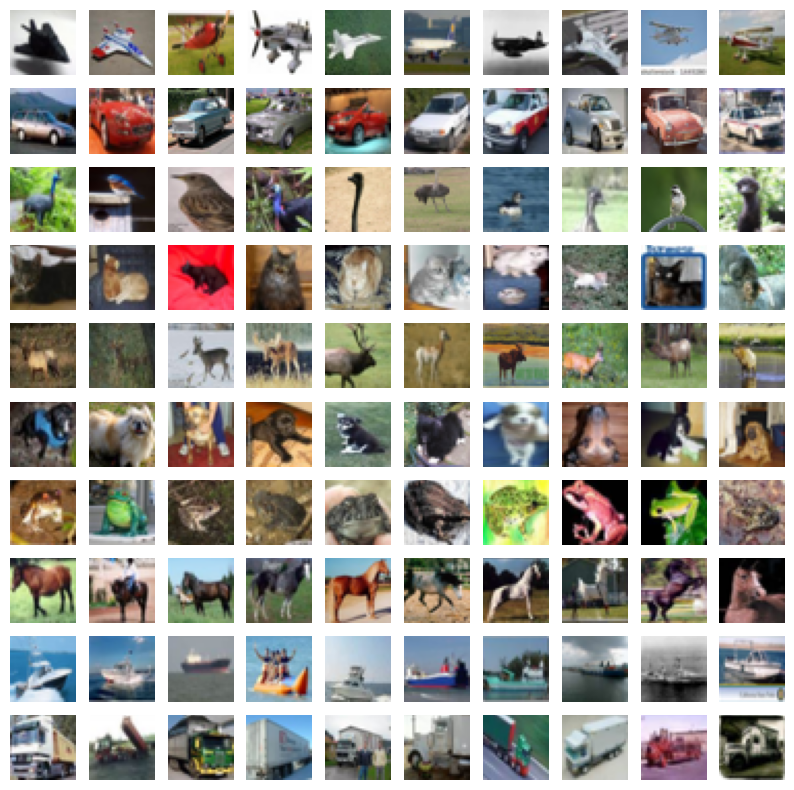

In [30]:
num_classes = 10
fig, axes = plt.subplots(num_classes, 10, figsize = (10, 10))
labels = np.array([t[1] for t in trainset])
for i in range(num_classes):
  indices = np.where(labels == i)[0]
  for j in range(10):
    axes[i,j].imshow(trainset[indices[j]][0].permute(1,2,0).numpy())
    axes[i,j].axis('off')
plt.show()

In [31]:
trainset[0][0].shape

torch.Size([3, 32, 32])

In [44]:
class CNN(nn.Module):
  def __init__(self, num_classes):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
    self.pooling1 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout1 = nn.Dropout(p=0.25)
    self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
    self.pooling2 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout2 = nn.Dropout(p=0.25)
    self.flatten = nn.Flatten()

    self.fc1 = nn.Linear(in_features=64*8*8, out_features=128)
    self.dropout3 = nn.Dropout(p=0.5)
    self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = self.pooling1(x)
    x = self.dropout1(x)
    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = self.pooling2(x)
    x = self.dropout2(x)
    x = self.flatten(x)
    x = F.relu(self.fc1(x))
    x = self.dropout3(x)
    x = self.fc2(x) ###  输出logits
    return x

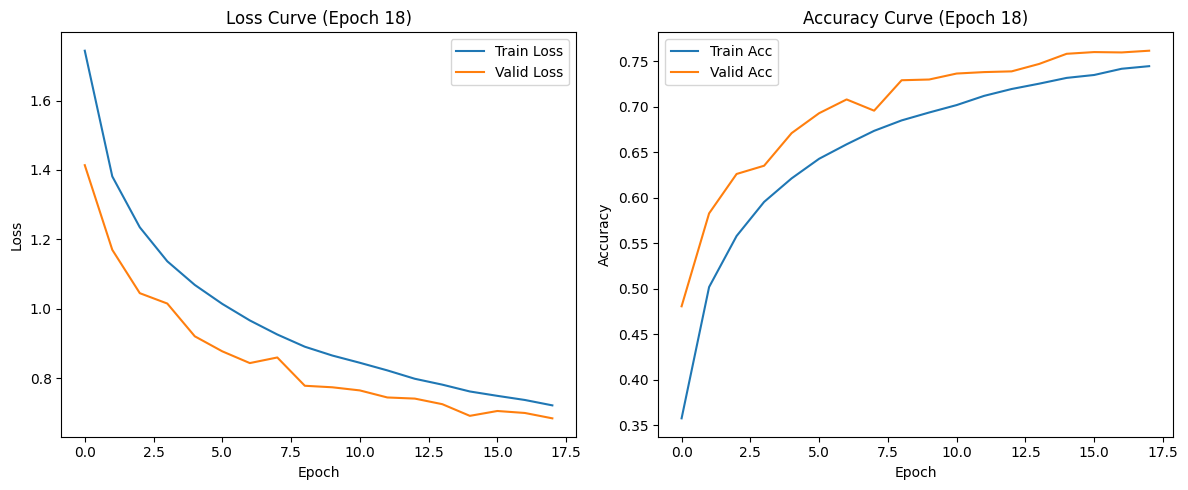

 32%|███▏      | 252/782 [00:03<00:06, 84.20it/s]

In [ ]:
### training
if not os.path.exists('./models'):
  os.mkdir('./models')

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model = CNN(10)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_loader = dataloader.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=6, pin_memory=True)
test_loader = dataloader.DataLoader(testset, batch_size=64, shuffle=False, num_workers=6, pin_memory=True)
train_losses = []
train_acces = []
test_losses = []
test_acces = []
max_iters = 100
count = 0
best_acc = 0
for epoch in range(max_iters):
  train_loss = 0
  train_acc = 0
  model.train()
  for i, batch in (enumerate(tqdm(train_loader))):
    x, y = batch
    x = x.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    train_loss += loss.detach().item()
    train_preds = torch.argmax(logits, dim=1)
    train_acc += (train_preds.detach() == y).float().mean().item()
  train_losses.append(train_loss/len(train_loader))
  train_acces.append(train_acc/len(train_loader))

  if len(test_loader) > 0:
    test_loss = 0
    test_acc = 0
    model.eval()
    with torch.no_grad():
      for i, batch in (enumerate(tqdm(test_loader))):
        x, y = batch
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        test_loss += loss.item()
        test_preds = torch.argmax(logits, dim=1)
        test_acc += (test_preds == y).float().mean().item()
    test_losses.append(test_loss/len(test_loader))
    test_acces.append(test_acc/len(test_loader))

    if test_acc > best_acc:
      best_acc = test_acc
      torch.save(model.state_dict(), './models/best_model.pth')
      print(f"Saving model with best acc {best_acc}...")
      count = 0
    else:
      count += 1
      if count > 20:
        break

    # ===== 每隔 10 个 epoch 刷新一次图 =====
    if (epoch + 1) % 1 == 0 or epoch == 0:
        clear_output(wait=True)   # 清掉上一个图，不重刷整个页面

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        if test_losses:
            plt.plot(test_losses, label='Valid Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'Loss Curve (Epoch {epoch+1})')

        plt.subplot(1, 2, 2)
        plt.plot(train_acces, label='Train Acc')
        if test_acces:
            plt.plot(test_acces, label='Valid Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title(f'Accuracy Curve (Epoch {epoch+1})')

        plt.tight_layout()
        plt.show()


tensor([[8],
        [2],
        [0],
        [1],
        [8]])